## Exercise 4
### Hydrogen Burning

In [20]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

For an easy access to the cross sections we import another package. With this package it is possible to read reaclib files and to get the cross sections at a specific temperature.  

In [21]:
from class_files.reaclib_class import reaclib

# For this, we have to give the path of the Reaclib file
r = reaclib("hburning_reactions.dat")
r.read_reaclib()
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'class_files'

In [ ]:
# With the class we can now access all reactions that are contained in the Reaclib
# For this we have to call the function "get_rate_at_temp", followed by the temperature in GK, 
# the reactants as a list, and the products as a list. The return value will be Avogadros number (NA)
# times the cross section at the given temperature.
# For example, we can access <ov>_pp * NA at 0.015 GK by:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])

NameError: name 'r' is not defined

In [ ]:
# Run winnet
! /home/teaching/WinNet/bin/winnet Hydrogen_burning.par >OUT 2>ERR

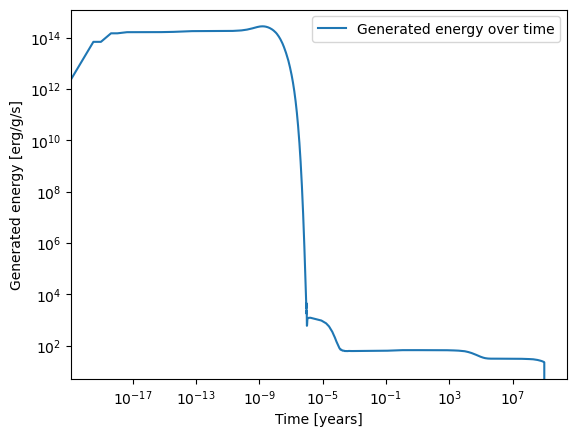

In [ ]:
data = np.loadtxt("generated_energyT0.015GK.dat", skiprows=1)

time = data[:, 0]
totalenergy = data[:, 1]

plt.plot(time / (365*24*3600), totalenergy, label="Generated energy over time")
plt.xlabel('Time [years]')
plt.ylabel('Generated energy [erg/g/s]')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

We can observe that the generated energy increased in the first few moments and then remains more or less constant over a long time period. After that it experiences two dip at around 1e-5 years, one being pretty sharp and the other one being more soft. In the end, the generated energy is somewhat constant again until it reaches zero at the end of the time interval.

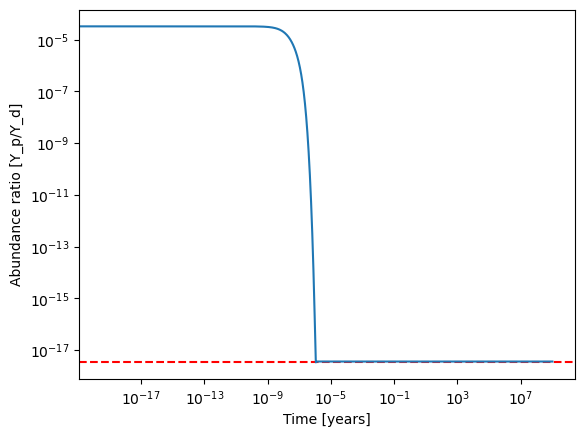

In [ ]:
trackT1 = np.loadtxt("tracked_nucleiT0.015GK.dat", skiprows=1)

timeT1 = trackT1[:, 0] 
Y_p = trackT1[:, 1] 
Y_d = trackT1[:, 2] 
Y_he3 = trackT1[:, 3] 
Y_he4 = trackT1[:, 4]

'''Looking up the reaction rates from another student since I cannot access the data from the reaclib file'''
R_pp = 8.104710278365027e-20
R_pd = 0.011189587220289314
plt.axhline(R_pp/(2*R_pd), color='red', linestyle='--')
plt.plot(time / (365*24*3600), Y_d / Y_p)
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_p/Y_d]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

In [ ]:
eqtime = 1e-6 * 365 * 24 * 60 * 60
eqtime

31.536000000000005

It takes about 1e-6 years to reach equilibrium, which is about 32 seconds. Upon reaching a sufficient temperature to start the pp-burning, the deuterium will almost instantly be "catched" in its equilibrium.
No, that is not a comparable timescale to the lifetime of a star, since the lifetime of a star is usually around 1e9 - 1e10 years. That means, that most of the time we can assume the equilibrium value for deuterium in numerical calculations.
Yes, you can identify the signatures of deuterium burning, but only in the early phases of stellar evolution. This is characterized by the very high initial energy generation, where the primordial deuterium burning takes place through the reaction $d(p,\gamma)^3\mathrm{He}$
.
Around 1e-6 years, the generated energy drops sharply, which marks the time where the deuterium is nearly exhausted.
No, it is not possible to measure the abundance of primordial deuterium in a star. This is because, within only 1e-6 years, the abundance drops from an already low value of 1e-5 to an even lower value of 1e-17. So, all of the primordial deuterium got burned.

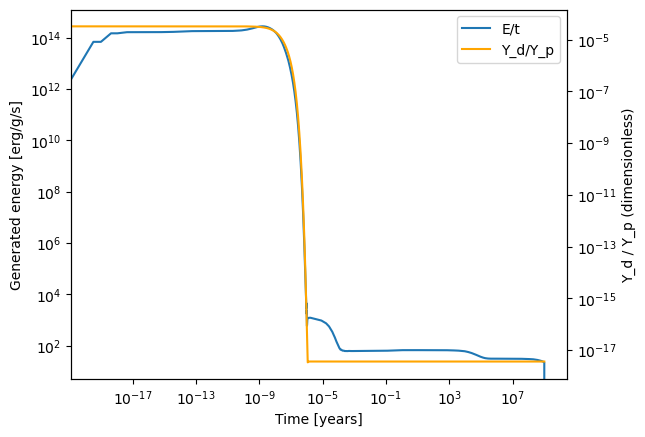

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_d / Y_p, color='orange', label="Y_d/Y_p")
ax2.set_ylabel('Y_d / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

We can see a very similar behavior of the generated energy and deuterium ration over time, especially when both graph decrease. I think it is possible to measure primordial deuterium abundances, because even with sloppy approximations we can see significantly similar results in both graphs, which points to promising data of deuterium abundance.

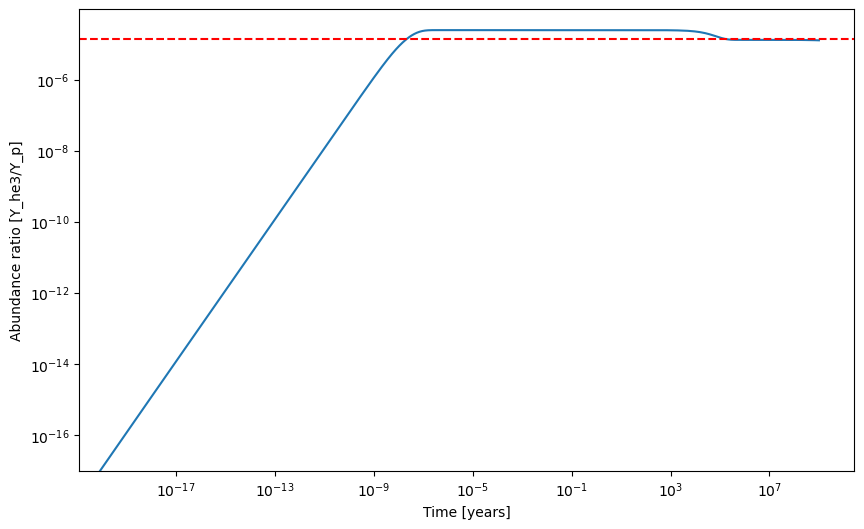

In [ ]:

R_pp = 8.104710278365027e-20
R_he3he3 = 2.219153470296946e-10
plt.figure(figsize=(10,6))
ratio_rate = np.sqrt(R_pp / (2*R_he3he3))
plt.plot(time / (365*24*3600), Y_he3 / Y_p)
plt.axhline(ratio_rate, color='red', linestyle = '--')
plt.xlabel('Time [years]') 
plt.ylabel('Abundance ratio [Y_he3/Y_p]') 
plt.xscale('log') 
plt.yscale('log')  
plt.show()

It takes about 1e6 years to reach the equilibrium value.
The abundance ratio first goes above its equilibrium value, because in the beginning $^3He$ production dominates through burning of primordial deuterium. It then overshoots, because it will be more produced then burned through $^3He$ - $^3He$ fusion, until the fusionrate catches up to the production rate.
Also, the time where $^3He$ reaches its true equilibrium correlates to the second drop in the generated energy plot.

C:\Users\Max\AppData\Local\Temp\ipykernel_11408\2740803029.py:34: UserWarning: The label '_child1' of <matplotlib.lines.Line2D object at 0x00000165BF1D6620> starts with '_'. It is thus excluded from the legend.
  ax1.legend(lines, labels, loc='best')


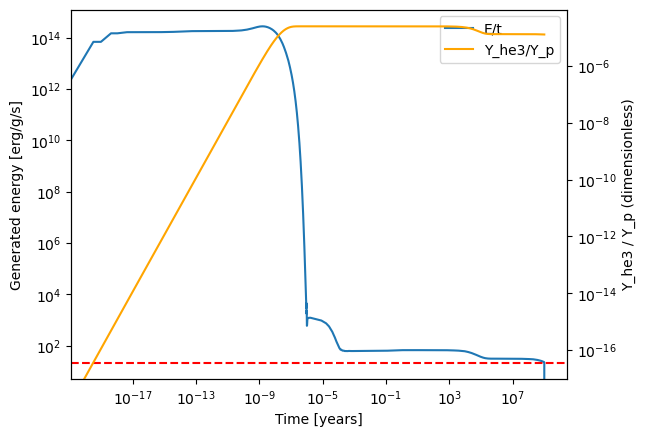

In [ ]:
Yp_eq=0.751
NA_sigma_pp=8.104710278365027e-20
NA_sigma_dp=0.011189587220289314
dpratio_eq = NA_sigma_pp / (2.0 * NA_sigma_dp)
NA_sigma_he3he3=2.219153470296946e-10
NA_sigma_pp=8.104710278365027e-20
he3pratio_eq =  np.sqrt(NA_sigma_pp/(2*NA_sigma_he3he3))
Yhe3_eq = he3pratio_eq/Yp_eq
Yd_eq = dpratio_eq/Yp_eq

Q_pp = 1.44
Q_dp = 5.49
Q_3he3he = 12.9 
rho = 100.0

#We now calculate the energy production
E_ppI= 0.5*rho*(Yp_eq**2)*NA_sigma_pp*Q_pp + 0.5*rho*(Yhe3_eq**2)*NA_sigma_he3he3*Q_3he3he + rho*Yd_eq*Yp_eq*NA_sigma_dp*Q_dp*1.60218e-6*6.022e23

fig, ax1 = plt.subplots()

ax1.plot(time / (365*24*3600), totalenergy, label="E/t")
ax1.set_xlabel('Time [years]')
ax1.set_ylabel('Generated energy [erg/g/s]')
ax1.set_xscale('log')
ax1.set_yscale('log')
plt.axhline(E_ppI, color='red', linestyle = '--')
ax2 = ax1.twinx()
ax2.plot(timeT1 / (365*24*3600), Y_he3 / Y_p, color='orange', label="Y_he3/Y_p")
ax2.set_ylabel('Y_he3 / Y_p (dimensionless)')
ax2.set_yscale('log')

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()

The generated energy reaches an almost constant value right below 1e2. The analytical estimatation (red dashed horizontal line) is almost perfect since it should be a bit higher. We can more or less reproduce the WinNET calculations.

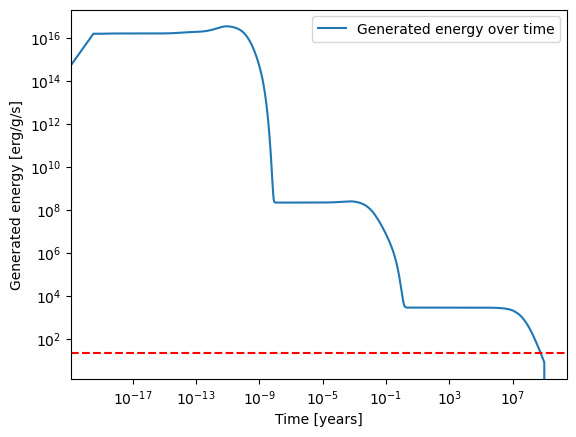

In [24]:
data2 = np.loadtxt("generated_energyT0.05GK.dat", skiprows=1)

NA_sigma_pp = 8.104710278365027e-20 
NA_sigma_dp = 0.011189587220289314
NA_sigma_he3he3 = 2.219153470296946e-10

he3pratio_eq =  np.sqrt(NA_sigma_pp/(2*NA_sigma_he3he3))
dpratio_eq = NA_sigma_pp / (2.0 * NA_sigma_dp)

Yp_eq=0.751
Yhe3_eq = he3pratio_eq/Yp_eq
Yd_eq = dpratio_eq/Yp_eq

Q_pp = 1.44
Q_dp = 5.49
Q_3he3he = 12.9 
rho = 100.0

E_ppI= 0.5*rho*(Yp_eq**2)*NA_sigma_pp*Q_pp + 0.5*rho*(Yhe3_eq**2)*NA_sigma_he3he3*Q_3he3he + rho*Yd_eq*Yp_eq*NA_sigma_dp*Q_dp*1.60218e-6*6.022e23

time = data2[:, 0]
totalenergy = data2[:, 1]

plt.plot(time / (365*24*3600), totalenergy, label="Generated energy over time")
plt.xlabel('Time [years]')
plt.ylabel('Generated energy [erg/g/s]')
plt.axhline(E_ppI, color='red', linestyle = '--')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

We can see, that for a given higher temperature, the generated energy has a faster and more complex drop than before. The simple approximations from before, can now not reproduce the WinNET calculations. First of all, the simplest reason for that could be, that a higher temperature just lead to a faster burning and the equilibrium will be achieved much faster. Also, higher temperature may activate more complex reactions such as pp-II and pp-III chains. This will also lead to a significant difference. Lastly, the pp-I chain is heavily dependent on temperature, which also underlines the previous statement